In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib_venn import venn2

fsize = 20
plt.rcParams.update({"font.size": fsize})
%config InlineBackend.figure_format = 'retina'

In [3]:
def load_evidence(fn):
    df = pd.read_json(fn)
    # Unwrap the 'source' column (contains a dictionary) into separate columns
    source_df = df['source'].apply(pd.Series)
    extracted_df = df['extracted'].apply(pd.Series).add_prefix('extracted_')
    derived_df = df['derived'].apply(pd.Series).add_prefix('derived_')
    # Combine the original DataFrame with the unwrapped columns
    df = pd.concat([df.drop(columns=['source', 'extracted', 'derived']), source_df, extracted_df, derived_df], axis=1)
    return df

In [5]:
f1_fn = "../../data/adipose_Emont2022/evidence_human/evidence.json"
f2_fn = "../../data/adipose_Vijay2019/evidence_human/evidence.json"


df1 = load_evidence(f1_fn)
df2 = load_evidence(f2_fn)

df1

,source_id,source_type,source_rationale,extracted_organism,extracted_cell_type_label,extracted_cell_source,extracted_cell_state,extracted_gene,derived_organism,derived_cell_type_id,derived_cell_type_label,derived_cell_source,derived_cell_state,derived_gene,derived_gene_id
0,text,text,We identified six distinct subpopulations of h...,homo_sapiens,human ASPCs,adipose,None,PDGFRA,homo_sapiens,None,human ASPCs,adipose,None,PDGFRA,ENSG00000134853
1,text,text,"For example, mASPC2 and hASPC2 are characteriz...",homo_sapiens,hASPC2,adipose,None,ALDH1A3,homo_sapiens,None,hASPC2,adipose,None,ALDH1A3,ENSG00000184254
2,text,text,"Similarly, mASPC4 and hASPC4 express Epha3 and...",homo_sapiens,hASPC4,adipose,None,EPHA3,homo_sapiens,None,hASPC4,adipose,None,EPHA3,ENSG00000044524
3,text,text,"Thus, the adipokines adiponectin and adipsin (...",homo_sapiens,hAd3,adipose,None,CFD,homo_sapiens,None,hAd3,adipose,None,CFD,ENSG00000197766
4,text,text,genes encoding insulin signalling components s...,homo_sapiens,hAd5,adipose,None,INSR,homo_sapiens,None,hAd5,adipose,None,INSR,ENSG00000171105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368,Extended Data Fig. 14i,img,marker shows sign of expression in figure,homo_sapiens,hAd4,adipose,sNuq-seq,NRCAM,homo_sapiens,None,hAd4,adipose,sNuq-seq,NRCAM,ENSG00000091129
369,Extended Data Fig. 14i,img,marker shows sign of expression in figure,homo_sapiens,hAd4,adipose,sNuq-seq,PCDH7,homo_sapiens,None,hAd4,adipose,sNuq-seq,PCDH7,ENSG00000169851
370,Extended Data Fig. 14i,img,marker shows sign of expression in figure,homo_sapiens,hAd4,adipose,sNuq-seq,PEMT,homo_sapiens,None,hAd4,adipose,sNuq-seq,PEMT,ENSG00000133027
371,Extended Data Fig. 14i,img,marker shows sign of expression in figure,homo_sapiens,hAd4,adipose,sNuq-seq,VGLL3,homo_sapiens,None,hAd4,adipose,sNuq-seq,VGLL3,ENSG00000206538


# Global gene comparison

In [10]:
def set_itx(a, b):
    return np.intersect1d(a, b).shape[0]
def set_itx_vals(a,b):
    return np.intersect1d(a,b)
def set_diff(a, b):
    return a.shape[0] - set_itx(a, b)
def create_venn(left, right, itx, set_a_name = "Set A", set_b_name = "Set B"):
    venn2(subsets = (left, right, itx), set_labels = (set_a_name, set_b_name))
    plt.show()


In [11]:
first = df1['derived_gene'].str.strip().str.upper()
second = df2['derived_gene'].str.strip().str.upper()
left  = set_diff(first, second)
itx   = set_itx(first, second)
right = set_diff(second, first)
itx_vals = set_itx_vals(first, second)

370 3 102 ['CFD' 'MSLN' 'PECAM1']


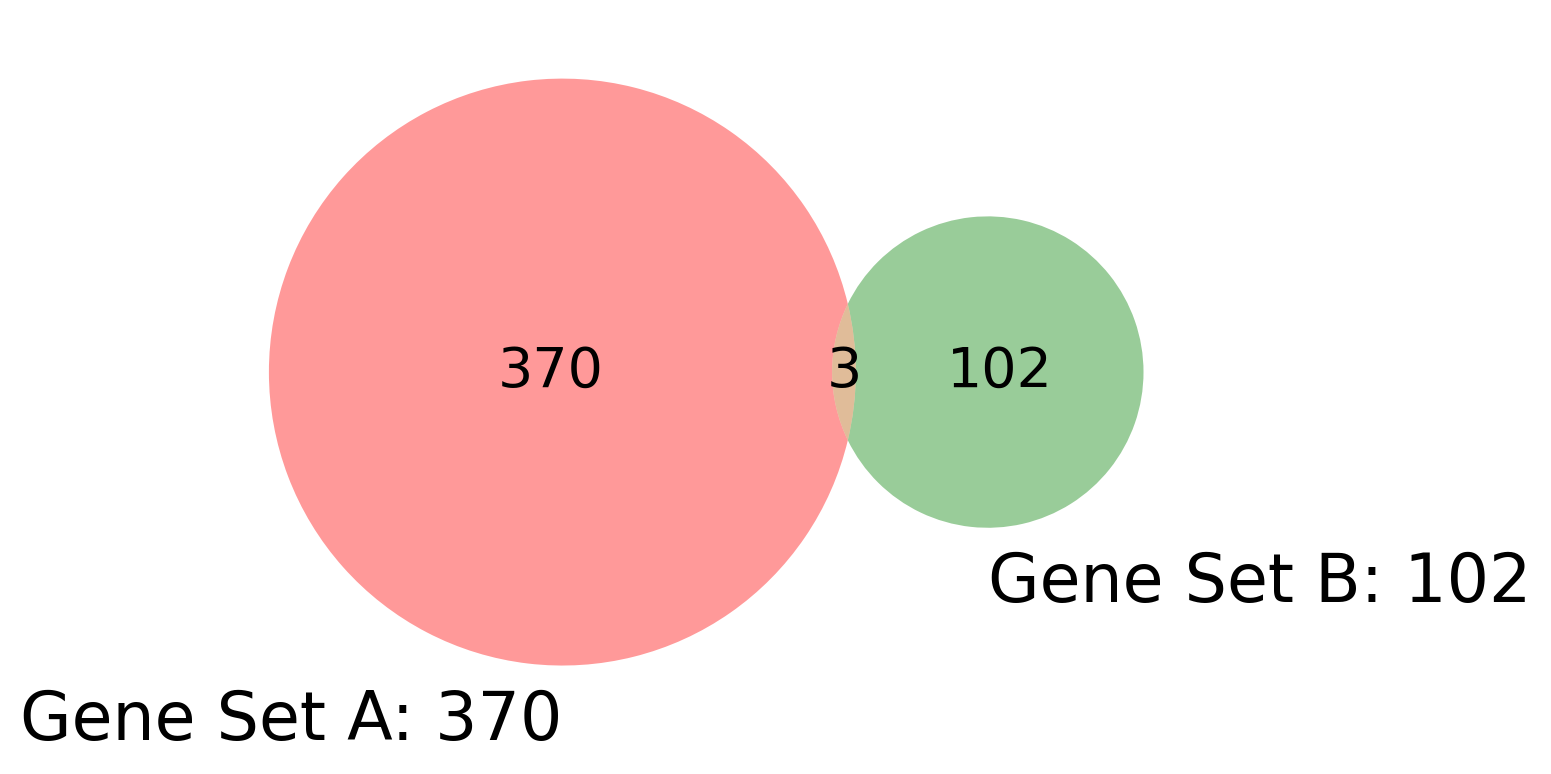

In [12]:
print(left, itx, right, itx_vals)
create_venn(left, right, itx, f'Gene Set A: {left}', f'Gene Set B: {right}')

# Global Celltype comparison

In [13]:
feature = 'derived_cell_type_label'
left  = set_diff(df1[feature].str.strip().str.upper(), df2[feature].str.strip().str.upper())
itx   = set_itx( df1[feature].str.strip().str.upper(), df2[feature].str.strip().str.upper())
right = set_diff(df2[feature].str.strip().str.upper(), df1[feature].str.strip().str.upper())
itx_vals = set_itx_vals( df1[feature].str.strip().str.upper(), df2[feature].str.strip().str.upper())

373 0 105 []


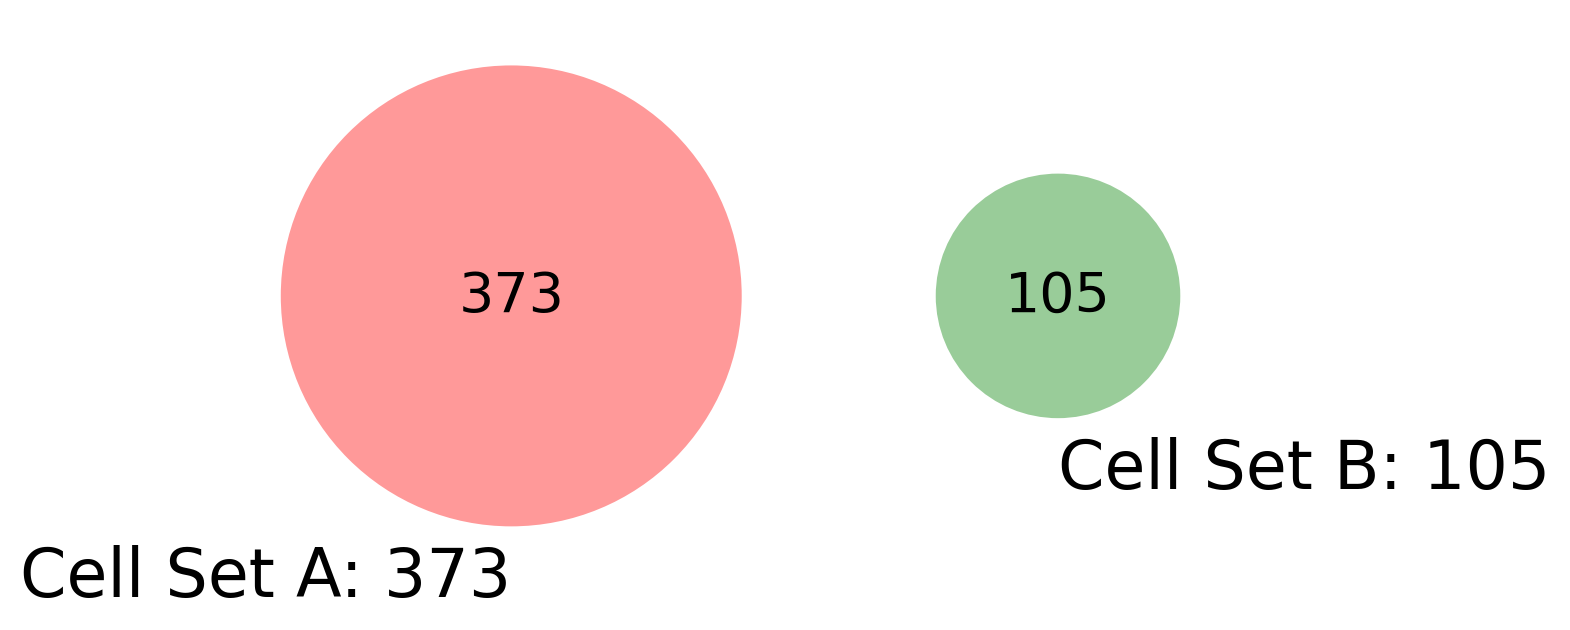

In [14]:
print(left, itx, right, itx_vals)
create_venn(left, right, itx, f'Cell Set A: {left}', f'Cell Set B: {right}')